# 03 · Modellazione e forecasting
**MICRO** (Random Forest, valore oggi) × **MACRO** (Prophet + ARIMA sul trend ISTAT Nord-ovest) → `predict_future_price(features, anni)`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import pandas as pd, numpy as np
pd.set_option('display.width', 120)

## Modello MICRO — Random Forest
Baseline OMI B3 integrata come feature `valore_zona_eur_mq`. Valutazione MAE/RMSE (5-fold).

In [2]:
from model_pipeline import train_micro, predict_price_today
micro_model, micro_metr = train_micro()
micro_metr

── MODELLO MICRO (Random Forest) ─────────────────────────────
  compravendite: 400 | MAE 23,755 € | RMSE 31,272 €
  importanza: metratura 65%, stato_conservazione 15%, valore_zona_eur_mq 13%, ascensore 3%


{'mae': 23754.628253739593, 'rmse': 31272.120774970175}

## Modello MACRO — Prophet vs ARIMA (backtest)
Su serie trimestrale corta ARIMA è il controllo obbligatorio; si sceglie il modello col RMSE minore sull'holdout.

In [3]:
from data_fetcher import fetch_istat_ipab
from model_pipeline import build_macro
istat = fetch_istat_ipab()
macro = build_macro(istat, anni=5)
macro.backtest

[ISTAT] scaricate 44 osservazioni reali (area=ITC).


── MODELLO MACRO (ISTAT IPAB Nord-ovest) ─────────────────────
  backtest holdout: Prophet RMSE 1.03 / MAPE 0.7%  |  ARIMA(2, 1, 2)+drift RMSE 3.97 / MAPE 2.9%
  modello scelto (RMSE minore): PROPHET
  indice oggi 123.0 -> a 5 anni 140.6 (rivalutazione +14.3%, CAGR +2.71%/anno)


{'prophet': {'rmse': 1.0299585667092477, 'mape': 0.00709898111583443},
 'arima': {'rmse': 3.973600339397046,
  'mape': 0.028619875966001733,
  'order': '(2, 1, 2)+drift'},
 'migliore': 'prophet'}

## Confronto grafico delle previsioni

[ISTAT] scaricate 44 osservazioni reali (area=ITC).


Salvato /home/user/BackPropBandits-815601-/andora_real_estate/reports/forecast_nordovest.png


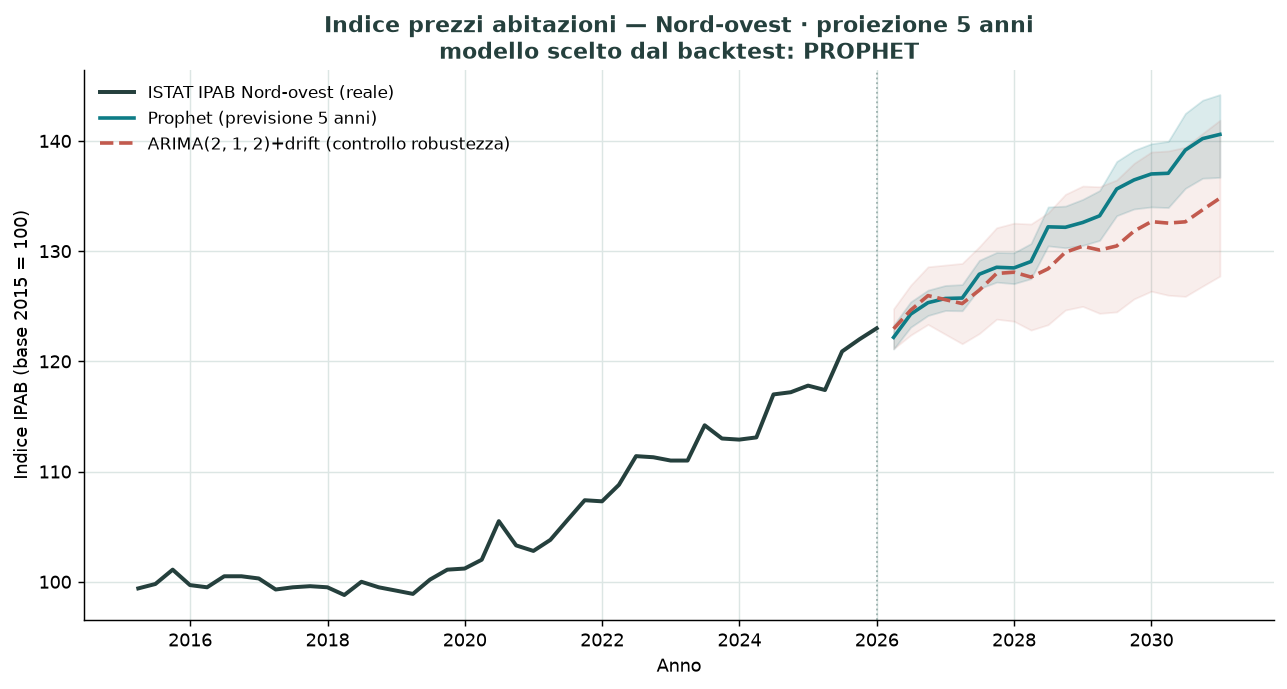

In [4]:
from make_report_assets import main as plot_forecast
plot_forecast()
from IPython.display import Image
Image('../reports/forecast_nordovest.png')

## Inferenza finale — Via Aurelia 111 a 5 anni

In [5]:
from model_pipeline import predict_future_price
civ111 = dict(metratura=85, piano=3, ascensore=1, classe_energetica='D',
              stato_conservazione=3, distanza_mare_km=0.2, box_auto=1)
res = predict_future_price(micro_model, macro, civ111, anni=5, micro_mae=micro_metr['mae'])
for k,v in res.items():
    print(f'{k:22} {v:,.0f}' if isinstance(v,(int,float)) and abs(v)>1 else f'{k:22} {v}')

prezzo_oggi            306,680
oggi_basso             282,925
oggi_alto              330,434
coeff_rivalutazione    0.14302972993163965
cagr_macro             0.027097105423705914
prezzo_futuro_atteso   350,544
forbice_bassa          314,434
forbice_alta           388,184
orizzonte_anni         5
modello_macro          prophet


> **Avvertenza.** La rivalutazione descrive il trend **di zona** (Nord-ovest), non la singola casa. Una previsione puntuale a 5 anni per un immobile non è affidabile: leggere la forbice come ordine di grandezza.